In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from iertools.read import read_sql
from dateutil.parser import parse

In [2]:
def carga_datos(f):
    
    sinv = read_sql(f,alias=True).data
    nombres = {
        'TECHO:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)': 'Is_TECHO',
        'VNORTE:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)': 'Is_VNORTE',
        'VOESTE:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)': 'Is_VOESTE'
    }
    sinv.rename(columns=nombres,inplace=True)
    return sinv


In [10]:
f = "../osm/005_CBs/run/eplusout.sql"
sinv = carga_datos(f)

f = "../osm/006_Protecciones/run/eplusout.sql"
conv = carga_datos(f)

columnas = conv.columns
columnas

Index(['ESTE:Zone Air Relative Humidity (%)', 'ESTE:Zone Air Temperature (C)',
       'Ti_ESTE', 'To',
       'FACE 13:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)',
       'FACE 15:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)',
       'FACE 16:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)',
       'FACE 18:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)',
       'FACE 19:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)',
       'FACE 1:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)',
       'FACE 20:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)',
       'FACE 21:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)',
       'FACE 22:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)',
       'FACE 23:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)',
       'FACE 2:Surface Outside Face Incident Sol

In [4]:
Iss = [columna for columna in columnas if "Is_" in columna]
Tis = [columna for columna in columnas if "Ti_" in columna]
Iss, Tis

(['Is_TECHO', 'Is_VNORTE', 'Is_VOESTE'], ['Ti_ESTE', 'Ti_OESTE'])

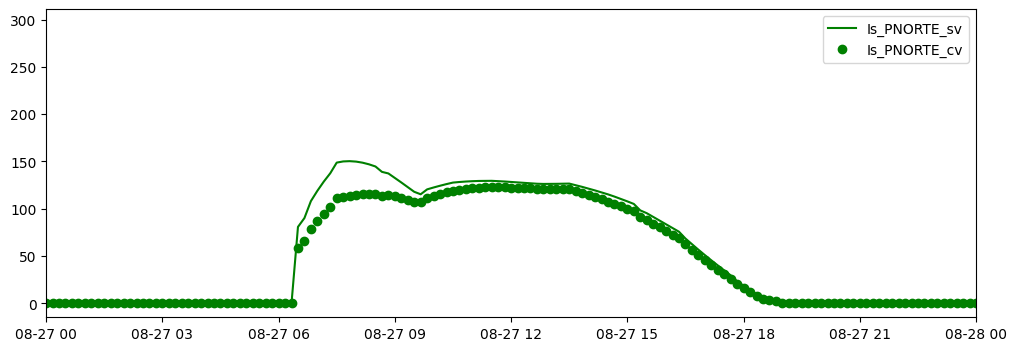

In [8]:
fig, ax = plt.subplots(figsize=(12,4),sharex=True)
f1 = parse("2006-08-27")
f2 = f1 + pd.Timedelta("1D")



ax.plot(sinv['FACE 6:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)'],"g-",label="Is_PNORTE_sv")
ax.plot(conv['FACE 6:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)'],"go",label="Is_PNORTE_cv")




ax.set_xlim(f1,f2)
ax.legend()
ax.legend()


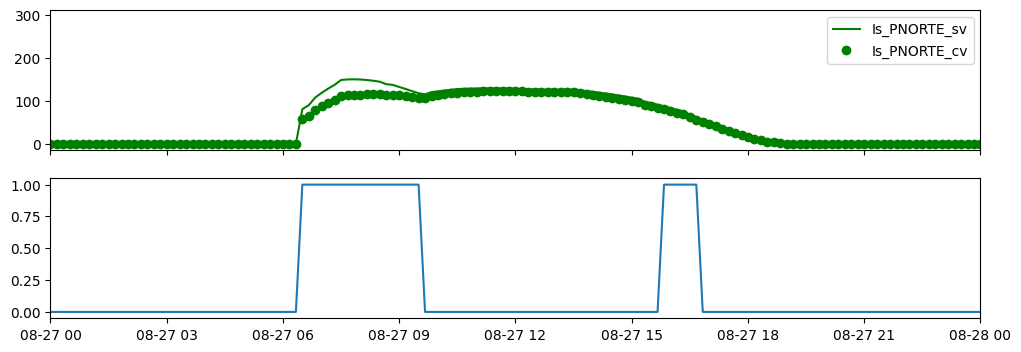

In [11]:
fig, ax = plt.subplots(2,1,figsize=(12,4),sharex=True)
f1 = parse("2006-08-27")
f2 = f1 + pd.Timedelta("1D")



ax[0].plot(sinv['FACE 6:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)'],"g-",label="Is_PNORTE_sv")
ax[0].plot(conv['FACE 6:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)'],"go",label="Is_PNORTE_cv")

ax[1].plot(conv['VNORTE:Surface Outside Face Sunlit Fraction ()'],label="fraccion sombreamiento")


ax[0].set_xlim(f1,f2)
ax[0].legend()
